# LoRA: Low-Rank Adaptation of Large Language Models

**Hu et al., 2021 · [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)**  
Edward Hu, Yelong Shen, Phillip Wallis, Zeyuan Allen-Zhu, Yuanzhi Li, Shean Wang, Lu Wang, Weizhu Chen · Microsoft Corporation

![LoRA: LOW-RANK ADAPTATION OF LARGE LANGUAGE MODELS - Abstract](assets/paper.png)


## Background

Large language models such as GPT, LLaMA and other LLMs are built with billions of parameters. These parameters are the values the model learns during training, and they allow the model to understand and generate language. A common way to adapt a pretrained model to a new task is full fine-tuning, which updates every parameter in the model using task-specific training data.

This can work well, but it creates several practical problems. Large models need a huge amount of GPU memory during training, and they also require extra memory for optimizer states, which makes training even more expensive. Each fine-tuned version of the model must store a full new set of weights, so checkpoint files become large. As models are getting larger and larger with more parameters and tokens, this problem increases to a critical point hard to ignore.

LoRA stands for **Low-Rank Adaptation**. It was introduced as a more efficient way to adapt large pretrained models. LoRA solves this by keeping the original model weights frozen. Instead of changing the whole model, it trains only a small number of new parameters. These small updates are made using two low-rank matrices. In simple words, LoRA does not build a whole new model for each task. It adds a small adapter to the existing model.

This design gives some advantages. Training becomes cheaper because only a small number of parameters need to be updated, memory usage is reduced, and the final task-specific checkpoint is much smaller, which makes it easier to save, share, and deploy. Finally, the original pretrained model stays unchanged, so the same base model can support many different LoRA adapters for different tasks.



## Why Existing Solutions Are Not Enough

Before LoRA, two broad families of parameter-efficient adaptation were already well known. The paper argues that each has a drawback LoRA is designed to avoid.

**Adapter layers**. Adapter layers add small extra neural network modules inside the Transformer. Only these small modules are trained, while most of the model is frozen. This sounds efficient, adapters still create a problem during inference. Even though the adapter modules are small, they are added into the model’s forward pass. This means the model has extra steps to compute every time it answers.

**Prompt / prefix tuning**. Prompt or prefix tuning does not change the model weights. Instead, it adds special trainable tokens at the beginning of the input. This also saves parameters, but it has two problems. First, those special tokens take up space in the context window. For example, if the model can read 2,048 tokens and prefix tuning uses 100 tokens, then fewer tokens are left for the real task input. Second, prefix tuning can be hard to optimize. Adding more prefix tokens does not always improve performance. Sometimes performance goes up, but sometimes it goes down.

| Method         | Main idea                   | Main problem                                          |
| -------------- | --------------------------- | ----------------------------------------------------- |
| Adapter layers | Add small trainable layers  | Can slow down inference                               |
| Prefix tuning  | Add trainable prompt tokens | Uses context length and can be hard to optimize       |
| LoRA           | Add low-rank weight updates | Avoids extra inference latency and keeps input length |


## LoRA Architecture
LoRA's central claim is that the *update* $\Delta W$ learned during adaptation has low intrinsic rank, so it is wasteful to represent $\Delta W$ as a full matrix. Instead, LoRA factorizes it as $\Delta W = B A$ with $B \in \mathbb{R}^{d\times r}$, $A \in \mathbb{R}^{r\times k}$ and $r \ll \min(d, k)$. The pretrained $W_0$ is frozen; only $B$ and $A$ are trained.

Suppose we have a pretrained model $P_{\Phi_0}(y \mid x)$ with parameters $\Phi_0$, and we want to adapt it to a downstream dataset $\mathcal{Z} = \{(x_i, y_i)\}_{i=1}^N$.

**Full fine-tuning** searches for a new parameter vector $\Phi_0 + \Delta\Phi$ by maximizing

$$
\max_{\Phi}\; \sum_{(x, y) \in \mathcal{Z}} \sum_{t=1}^{|y|} \log P_{\Phi}(y_t \mid x, y_{<t})
$$

and the update $\Delta\Phi$ has the same dimension as $\Phi_0$.

**Parameter-efficient adaptation** factorizes the update through a much smaller parameter set $\Theta$ with $|\Theta| \ll |\Phi_0|$:

$$
\Delta\Phi \;=\; \Delta\Phi(\Theta), \qquad
\max_{\Theta}\; \sum_{(x, y) \in \mathcal{Z}} \sum_{t=1}^{|y|} \log P_{\Phi_0 + \Delta\Phi(\Theta)}(y_t \mid x, y_{<t}).
$$

LoRA is one particular choice of the encoding $\Delta\Phi(\Theta)$: for each targeted pretrained matrix $W_0 \in \mathbb{R}^{d \times k}$ the update is

$$
\Delta W \;=\; B A, \qquad B \in \mathbb{R}^{d \times r}, \;\; A \in \mathbb{R}^{r \times k}, \;\; r \ll \min(d, k).
$$

At inference, the model sees a single effective matrix $W = W_0 + B A$, so there is no architectural overhead.

The schematic below shows the two computational paths, frozen base and trainable low-rank update, that are combined at the output.

![Lora Image](assets/lora.png)

[2]



For a targeted pretrained matrix $W_0 \in \mathbb{R}^{d \times k}$, LoRA represents the adaptation update as

$$
\Delta W \;=\; B A, \qquad B \in \mathbb{R}^{d \times r}, \;\; A \in \mathbb{R}^{r \times k}, \;\; r \ll \min(d, k).
$$

The effective weight used in the forward pass is $W = W_0 + \Delta W = W_0 + B A$. For an input $x$,

$$
h \;=\; W_0\, x \;+\; \frac{\alpha}{r}\, B A\, x .
$$

Four parts of LoRA’s design are especially important.

- **Initialization.** $A$ is initialized with a Gaussian, and $B$ is initialized to zero. At step 0, $\Delta W = B A = 0$, so the model starts exactly at the pretrained function. So it's a safe starting point.
- **Scaling $\alpha / r$.** The update is multiplied by $\alpha/r$. This makes training roughly rank-agnostic: when we change $r$ we do not need to re-tune the learning rate. The paper sets $\alpha$ to the first $r$ they try and leaves it there.
- **Why small $r$?** The paper's hypothesis is that the task-specific update lives in a very low-dimensional subspace. The extreme result from the paper's Table 6 is that $r = 1$ or $r = 2$ is often enough for GPT-3 adaptation.
- **No extra parameters in the base path.** $W_0$ is frozen. No optimizer state is allocated for it, which is where the memory savings come from.

![Lora factorization](assets/factorization.png)

## LoRA Implementation

The following code shows a simple PyTorch implementation of LoRA for a linear layer. It is not a full language model implementation, but it demonstrates the main idea of LoRA clearly.

A normal linear layer uses a weight matrix $W_0$. LoRA keeps this original weight frozen and trains only two small matrices: $A$ and $B$.

Instead of changing the full weight matrix, LoRA learns a small update:

$$
\Delta W = BA
$$

So the output becomes:

$$
y = W_0x + \frac{\alpha}{r}BAx
$$

Here, $r$ is small, so LoRA trains far fewer parameters than full fine-tuning.

In the code, $B$ starts as zero, so the LoRA update is also zero at the beginning. This means the layer first behaves exactly like the original pretrained layer.

The code also has `merge()` and `unmerge()` functions. After training, `merge()` adds the LoRA update into the original weight, so inference runs like a normal linear layer with no extra cost.

We will use PyTorch, NumPy, TorchVision, and Matplotlib for this experiment. PyTorch is used to build and train the model, NumPy is used for numerical work, and Matplotlib is used to plot the results.

We also set a random seed to make the experiment more consistent. The code checks whether a GPU is available and uses it if possible; otherwise, it runs on the CPU. It's a minimal LoRa experiment so It designed to run on the CPU.

In [1]:
!pip install torch numpy torchvision matplotlib

  Using cached torch-2.11.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached numpy-2.4.4-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached cuda_bindings-13.2.0-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.3 kB)
  Using cached nvidia_cudnn_cu13-9.19.0.56-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.0-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.28.9-py3-none-manylinux_2_18_x86_64.whl.metadata (2.0 kB)
  Using cached 

In [2]:
import math, time, copy
from typing import Sequence, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device = {device}")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})


torch 2.11.0+cu130 | device = cpu


In [3]:
class LoRALinear(nn.Module):
    """A linear layer with a frozen pretrained weight W0 and a trainable
    low-rank update dW = (alpha / r) * B A.

    Forward pass:
        y = W0 x + b + (alpha/r) B A x     (unmerged)
        y = (W0 + (alpha/r) B A) x + b     (after .merge())
    """
    def __init__(self, in_features: int, out_features: int,
                 r: int = 4, alpha: float = 1.0, bias: bool = True):
        super().__init__()
        self.in_features, self.out_features = in_features, out_features
        self.r = r
        self.alpha = alpha
        self.scaling = (alpha / r) if r > 0 else 0.0

        # W0 and bias: the pretrained weight in paper terms.
        self.base = nn.Linear(in_features, out_features, bias=bias)

        if r > 0:
            self.A = nn.Parameter(torch.empty(r, in_features))
            self.B = nn.Parameter(torch.zeros(out_features, r))
            nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))   # A ≠ 0
            # B stays at 0, so ΔW = BA = 0 at initialization
        else:
            self.register_parameter("A", None)
            self.register_parameter("B", None)

        self.merged = False

    def forward(self, x):
        base_out = self.base(x)
        if self.r == 0 or self.merged:
            return base_out
        # Compute B A x as two linear applications — cheaper than materializing ΔW.
        return base_out + F.linear(F.linear(x, self.A), self.B) * self.scaling

    @torch.no_grad()
    def delta_w(self):
        if self.r == 0: return torch.zeros_like(self.base.weight)
        return self.scaling * (self.B @ self.A)

    @torch.no_grad()
    def merge(self):
        if self.r > 0 and not self.merged:
            self.base.weight.add_(self.delta_w()); self.merged = True

    @torch.no_grad()
    def unmerge(self):
        if self.r > 0 and self.merged:
            self.base.weight.sub_(self.delta_w()); self.merged = False

    def freeze_base(self):
        self.base.weight.requires_grad_(False)
        if self.base.bias is not None:
            self.base.bias.requires_grad_(False)

    def extra_repr(self):
        return f"in={self.in_features}, out={self.out_features}, r={self.r}, α={self.alpha}"

The forward pass has two paths that are summed:

1. A **frozen base path**: $W_0 x + b$.
2. A **trainable low-rank path**: $\frac{\alpha}{r} B A x$.

The low-rank path runs in two cheap matmuls because $r$ is small:
$$
x \;\xrightarrow{A}\; z \in \mathbb{R}^r \;\xrightarrow{B}\; \Delta h \in \mathbb{R}^d .
$$
At inference we fold the two paths into one matrix ($W = W_0 + \frac{\alpha}{r} B A$) and the extra cost disappears.

The diagram below shows the two paths; the code cell after it verifies three invariants: (i) at init the LoRA layer equals its base, (ii) after perturbing $A$ and $B$, merged == unmerged, and (iii) `unmerge()` restores bit-for-bit.

![Forward Image](assets/forward.png)

In [4]:
# Sanity checks for LoRALinear
torch.manual_seed(0)
layer = LoRALinear(16, 8, r=4, alpha=4.0)
x = torch.randn(3, 16)

# (i) at init, output equals the base Linear
ref = F.linear(x, layer.base.weight, layer.base.bias)
assert torch.allclose(layer(x), ref, atol=1e-6)

# (ii) after perturbing A, B, unmerged == merged
with torch.no_grad():
    layer.A.normal_(0, 0.1); layer.B.normal_(0, 0.1)
y_unmerged = layer(x).clone()
layer.merge();   y_merged   = layer(x).clone()
layer.unmerge(); y_restored = layer(x).clone()

print(f"init         : max |layer(x) - base(x)| = {(layer(x) - ref).abs().max():.2e}")
print(f"merge check  : max |unmerged - merged|  = {(y_unmerged - y_merged).abs().max():.2e}")
print(f"unmerge check: max |unmerged - restored|= {(y_unmerged - y_restored).abs().max():.2e}")

init         : max |layer(x) - base(x)| = 1.45e-01
merge check  : max |unmerged - merged|  = 2.38e-07
unmerge check: max |unmerged - restored|= 1.19e-07


## Model Training

LoRA is trained with an ordinary supervised loop. What is unusual is the set of trainable parameters. We walk through the sub-parts of the loop.

### Freezing the base and selecting the trainable set

Training logic:

1. Load the pretrained checkpoint into the model (base weights take their pretrained values; $A$ gets a fresh Gaussian, $B$ is 0).
2. Freeze **all** parameters.
3. Unfreeze **only** the $A$ and $B$ tensors inside each `LoRALinear`.
4. Pass that small subset to the optimizer.

Because optimizer state (Adam: two moment tensors per parameter) scales with the number of **trainable** parameters, freezing the base gives a roughly proportional memory saving.

### Initialization and the $\alpha/r$ scale

Keeping $B = 0$ at init is what makes LoRA "safe": at step 0 the adapted model is identical to the pretrained model, so the optimizer sees a loss landscape that is continuous with pretraining rather than a random perturbation of it.

The scaling factor $\alpha/r$ is paper-motivated: with Adam, tuning $\alpha$ is roughly equivalent to tuning the learning rate, so the paper just sets $\alpha$ equal to the first $r$ they try and keeps it fixed across rank sweeps.

### Merging at deployment

Once training is done, `merge()` folds $BA$ into $W_0$ in place, leaving one plain `nn.Linear` layer. Inference cost is then exactly the same as the pretrained model, no adapter blocks, no extra branches. If we want to swap tasks we `unmerge()` and load a different $\{A, B\}$ pair.

### Optimizer, loss, regularization

Nothing exotic is needed. We use **Adam** with a small learning rate, plus standard cross-entropy for classification. Because only $A, B$ are trainable, weight decay should be applied to those tensors only. LoRA itself is already a strong regularizer, so in practice very little extra regularization is necessary.

The helpers below implement these steps.

In [5]:
def freeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad_(False)

def mark_lora_trainable(model: nn.Module):
    """Unfreeze A, B in every LoRALinear. Leaves everything elsse frozen."""
    for m in model.modules():
        if isinstance(m, LoRALinear) and m.r > 0:
            m.A.requires_grad_(True)
            m.B.requires_grad_(True)

def count_params(model: nn.Module) -> Tuple[int, int]:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def merge_all(model: nn.Module):
    for m in model.modules():
        if isinstance(m, LoRALinear): m.merge()

def unmerge_all(model: nn.Module):
    for m in model.modules():
        if isinstance(m, LoRALinear): m.unmerge()

def save_lora(model: nn.Module, path: str):
    state = {f"{n}.A": m.A.detach().cpu() for n, m in model.named_modules()
             if isinstance(m, LoRALinear) and m.r > 0}
    state.update({f"{n}.B": m.B.detach().cpu() for n, m in model.named_modules()
                  if isinstance(m, LoRALinear) and m.r > 0})
    torch.save(state, path)

def load_lora(model: nn.Module, path: str):
    state = torch.load(path, map_location="cpu")
    for n, m in model.named_modules():
        if isinstance(m, LoRALinear) and m.r > 0:
            m.A.data.copy_(state[f"{n}.A"])
            m.B.data.copy_(state[f"{n}.B"])


A minimal training loop takes the parameters with requires_grad=True and runs Adam on them. The same loop works for full fine-tuning, where everything is trainable, and for LoRA, where only $A$ and $B$ are trainable.

In [6]:
def train_classifier(model, train_loader, val_loader, epochs=5, lr=1e-3, weight_decay=0.0, log=True):
    model.to(device)
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(trainable, lr=lr, weight_decay=weight_decay)
    hist = {"tr_loss": [], "va_loss": [], "va_acc": [], "time": []}

    for ep in range(epochs):
        t0 = time.time()
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb); loss = F.cross_entropy(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            vl_losses, correct, total = [], 0, 0
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                vl_losses.append(F.cross_entropy(logits, yb).item())
                correct += (logits.argmax(-1) == yb).sum().item()
                total   += yb.size(0)

        hist["tr_loss"].append(float(np.mean(tr_losses)))
        hist["va_loss"].append(float(np.mean(vl_losses)))
        hist["va_acc"].append(correct / total)
        hist["time"].append(time.time() - t0)

        if log:
            print(f"  epoch {ep+1:>2} | tr_loss {hist['tr_loss'][-1]:.4f} "
                  f"| va_loss {hist['va_loss'][-1]:.4f} "
                  f"| va_acc {hist['va_acc'][-1]:.3f} "
                  f"| {hist['time'][-1]:.2f}s")
    return hist


**Setup.** A small 3-layer MLP. We pretrain it on digits **0–4** (a 5-class problem), then adapt it to digits **5–9**. We compare two adaptation strategies:

- **Full fine-tuning** — every parameter trainable.
- **LoRA** — base frozen, low-rank updates inserted into the two hidden `nn.Linear` layers.

We load MNIST once via `torchvision` and split it by label:

- **Task A** (pretraining): digits 0–4.
- **Task B** (adaptation): digits 5–9, relabeled 0–4.

In [7]:
# MNIST loading. The first run downloads ~10 MB into ./data; subsequent runs reuse it.
from torchvision import datasets, transforms

tfm = transforms.Compose([transforms.ToTensor()])  # values in [0,1], shape (1,28,28)

mnist_train_full = datasets.MNIST(root="./data", train=True,  download=True, transform=tfm)
mnist_test_full  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

def split_by_label(dataset, keep_labels, relabel=True, max_per_class=None):
    """Return a TensorDataset containing only examples whose label is in
    `keep_labels`. If `relabel=True`, map those labels to 0..len(keep_labels)-1."""
    xs, ys = [], []
    per_class_count = {c: 0 for c in keep_labels}
    label_map = {c: i for i, c in enumerate(keep_labels)} if relabel else None
    for i in range(len(dataset)):
        x, y = dataset[i]
        y = int(y)
        if y in keep_labels:
            if max_per_class is not None and per_class_count[y] >= max_per_class:
                continue
            xs.append(x.view(-1))
            ys.append(label_map[y] if relabel else y)
            per_class_count[y] += 1
    X = torch.stack(xs); Y = torch.tensor(ys, dtype=torch.long)
    return TensorDataset(X, Y)

# Task A: digits 0-4. Task B: digits 5-9 (relabeled 0-4).
task_a_train = split_by_label(mnist_train_full, keep_labels=[0,1,2,3,4], max_per_class=600)
task_a_test  = split_by_label(mnist_test_full,  keep_labels=[0,1,2,3,4])

task_b_train = split_by_label(mnist_train_full, keep_labels=[5,6,7,8,9], max_per_class=600)
task_b_test  = split_by_label(mnist_test_full,  keep_labels=[5,6,7,8,9])

INPUT_DIM = task_a_train[0][0].numel()
print(f"Input dim: {INPUT_DIM}")
print(f"Task A: train={len(task_a_train)}  test={len(task_a_test)}")
print(f"Task B: train={len(task_b_train)}  test={len(task_b_test)}")

BS = 128
loader = lambda ds, shuffle: DataLoader(ds, batch_size=BS, shuffle=shuffle)
loaders_a = (loader(task_a_train, True), loader(task_a_test, False))
loaders_b = (loader(task_b_train, True), loader(task_b_test, False))


100.0%
100.0%
100.0%
100.0%


Input dim: 784
Task A: train=3000  test=5139
Task B: train=3000  test=4861


A three-linear-layer MLP with ReLU activations. We apply LoRA to the two **hidden** linear layers (`fc1`, `fc2`). Picking `lora_r=0` disables LoRA and turns the wrapper into a plain `nn.Linear`, so the same class can be used for both full fine-tuning and LoRA adaptation.

In [8]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=784, hidden=(256, 128), n_classes=5, lora_r=0, lora_alpha=1.0):
        super().__init__()
        h1, h2 = hidden
        self.fc1  = LoRALinear(in_dim, h1,        r=lora_r, alpha=lora_alpha)
        self.fc2  = LoRALinear(h1,     h2,        r=lora_r, alpha=lora_alpha)
        self.head = LoRALinear(h2,     n_classes, r=0)   # classifier head stays plain
        self.act  = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.head(x)

def make_mlp(lora_r=0, lora_alpha=4.0, seed=0):
    torch.manual_seed(seed)
    return TinyMLP(in_dim=INPUT_DIM, hidden=(256, 128), n_classes=5,
                   lora_r=lora_r, lora_alpha=lora_alpha)

# Parameter count cheat sheet for the architecture we will use
full_ref = make_mlp(lora_r=0)
for p in full_ref.parameters(): p.requires_grad_(True)
tot_full, tr_full = count_params(full_ref)

lora_ref = make_mlp(lora_r=4)
freeze_all(lora_ref); mark_lora_trainable(lora_ref)
tot_lora, tr_lora = count_params(lora_ref)

print(f"Full FT         : total = {tot_full:>7}   trainable = {tr_full:>7}   "
      f"({100*tr_full/tot_full:5.2f}%)")
print(f"LoRA (r=4, fc1,fc2): total = {tot_lora:>7}   trainable = {tr_lora:>7}   "
      f"({100*tr_lora/tot_lora:5.2f}%)")
print(f"Adam optimizer-state reduction ≈ {tr_full / max(tr_lora, 1):.1f}×")


Full FT         : total =  234501   trainable =  234501   (100.00%)
LoRA (r=4, fc1,fc2): total =  240197   trainable =    5696   ( 2.37%)
Adam optimizer-state reduction ≈ 41.2×


### Pretraining on Task A (digits 0–4)

We pretrain  LoRA-free MLP on digits 0–4 for a few epochs, then save its weights. Both adaptation strategies in the next section start from this exact checkpoint.


In [9]:
print("=== Pretraining on Task A (digits 0-4) ===")
base = make_mlp(lora_r=0)
for p in base.parameters(): p.requires_grad_(True)
pre_hist = train_classifier(base, *loaders_a, epochs=5, lr=1e-3)
pretrained_state = copy.deepcopy(base.state_dict())


=== Pretraining on Task A (digits 0-4) ===
  epoch  1 | tr_loss 0.8164 | va_loss 0.1913 | va_acc 0.948 | 0.32s
  epoch  2 | tr_loss 0.1576 | va_loss 0.1249 | va_acc 0.962 | 0.16s
  epoch  3 | tr_loss 0.1181 | va_loss 0.1334 | va_acc 0.962 | 0.14s
  epoch  4 | tr_loss 0.0931 | va_loss 0.0915 | va_acc 0.974 | 0.14s
  epoch  5 | tr_loss 0.0614 | va_loss 0.0873 | va_acc 0.978 | 0.20s


### Adapting to Task B (digits 5–9)

Both runs start from `pretrained_state`. The **full-FT** run unfreezes everything. The **LoRA** run freezes everything, then unfreezes $A, B$ in `fc1` and `fc2`. The classifier head (`head`) is always re-initialized and always trainable, because the pretrained head has been solving a different classification problem. This is the usual practice for classifier-head transfer.

In [10]:
def load_pretrained(model, state):
    own = model.state_dict()
    for k, v in state.items():
        if k in own and own[k].shape == v.shape:
            own[k].copy_(v)
    model.load_state_dict(own)

# --- (a) Full fine-tuning ---
print("=== Task B: full fine-tuning ===")
m_ft = make_mlp(lora_r=0)
load_pretrained(m_ft, pretrained_state)
# re-init classifier head (Task B has different classes)
nn.init.kaiming_uniform_(m_ft.head.base.weight, a=math.sqrt(5))
nn.init.zeros_(m_ft.head.base.bias)
for p in m_ft.parameters(): p.requires_grad_(True)
tr_full_b = count_params(m_ft)[1]
print(f"trainable params = {tr_full_b:,}")
hist_ft = train_classifier(m_ft, *loaders_b, epochs=5, lr=1e-3)

# --- (b) LoRA adaptation ---
print("\n=== Task B: LoRA (r=4, fc1, fc2) ===")
m_lo = make_mlp(lora_r=4, lora_alpha=4.0)
load_pretrained(m_lo, pretrained_state)
nn.init.kaiming_uniform_(m_lo.head.base.weight, a=math.sqrt(5))
nn.init.zeros_(m_lo.head.base.bias)
freeze_all(m_lo)
mark_lora_trainable(m_lo)
# The classifier head has no pretrained meaning for Task B, so unfreeze it too.
m_lo.head.base.weight.requires_grad_(True)
m_lo.head.base.bias.requires_grad_(True)
tr_lora_b = count_params(m_lo)[1]
print(f"trainable params = {tr_lora_b:,}  ({100*tr_lora_b/count_params(m_lo)[0]:.2f}% of total)")
hist_lo = train_classifier(m_lo, *loaders_b, epochs=5, lr=1e-3)


=== Task B: full fine-tuning ===
trainable params = 234,501
  epoch  1 | tr_loss 0.9064 | va_loss 0.4845 | va_acc 0.851 | 0.17s
  epoch  2 | tr_loss 0.3152 | va_loss 0.2899 | va_acc 0.914 | 0.25s
  epoch  3 | tr_loss 0.2009 | va_loss 0.2318 | va_acc 0.929 | 0.58s
  epoch  4 | tr_loss 0.1547 | va_loss 0.1971 | va_acc 0.937 | 0.28s
  epoch  5 | tr_loss 0.1215 | va_loss 0.1818 | va_acc 0.940 | 0.32s

=== Task B: LoRA (r=4, fc1, fc2) ===
trainable params = 6,341  (2.64% of total)
  epoch  1 | tr_loss 1.5749 | va_loss 1.2577 | va_acc 0.561 | 0.41s
  epoch  2 | tr_loss 1.0921 | va_loss 0.9109 | va_acc 0.703 | 0.25s
  epoch  3 | tr_loss 0.7642 | va_loss 0.6676 | va_acc 0.784 | 0.21s
  epoch  4 | tr_loss 0.5528 | va_loss 0.5183 | va_acc 0.833 | 0.18s
  epoch  5 | tr_loss 0.4261 | va_loss 0.4331 | va_acc 0.858 | 0.32s


## Results

1. **Training / validation loss curves**: both methods should drive loss down; LoRA may be slightly slower early on because $B$ starts at 0.
2. **Validation accuracy**: the eventual gap (if any) between full FT and LoRA.
3. **Trainable-parameter bar chart**: the main cost-side win.
4. **Summary table**: the same numbers compactly.

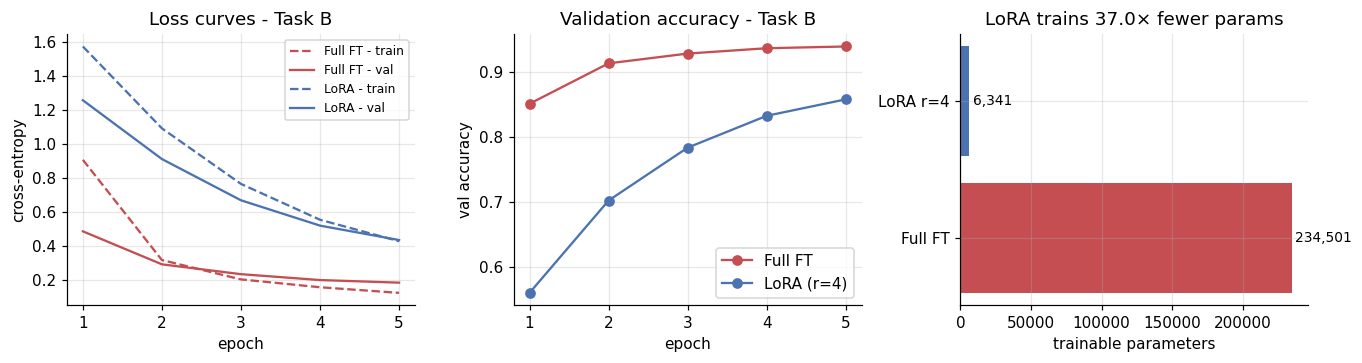

In [11]:
epochs = range(1, len(hist_ft["va_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

# (1) loss curves
ax = axes[0]
ax.plot(epochs, hist_ft["tr_loss"], "--", color="#c44e52", label="Full FT - train")
ax.plot(epochs, hist_ft["va_loss"], "-",  color="#c44e52", label="Full FT - val")
ax.plot(epochs, hist_lo["tr_loss"], "--", color="#4c72b0", label="LoRA - train")
ax.plot(epochs, hist_lo["va_loss"], "-",  color="#4c72b0", label="LoRA - val")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy")
ax.set_title("Loss curves - Task B"); ax.legend(fontsize=8)

# (2) validation accuracy
ax = axes[1]
ax.plot(epochs, hist_ft["va_acc"], "o-", color="#c44e52", label="Full FT")
ax.plot(epochs, hist_lo["va_acc"], "o-", color="#4c72b0", label="LoRA (r=4)")
ax.set_xlabel("epoch"); ax.set_ylabel("val accuracy")
ax.set_title("Validation accuracy - Task B"); ax.legend()

# (3) trainable-parameter bars
ax = axes[2]
ax.barh(["Full FT", "LoRA r=4"], [tr_full_b, tr_lora_b], color=["#c44e52", "#4c72b0"])
for i, v in enumerate([tr_full_b, tr_lora_b]):
    ax.text(v + max(tr_full_b, tr_lora_b)*0.01, i, f"{v:,}", va="center", fontsize=9)
ax.set_xlabel("trainable parameters")
ax.set_title(f"LoRA trains {tr_full_b / max(tr_lora_b, 1):.1f}× fewer params")

plt.tight_layout(); plt.show()


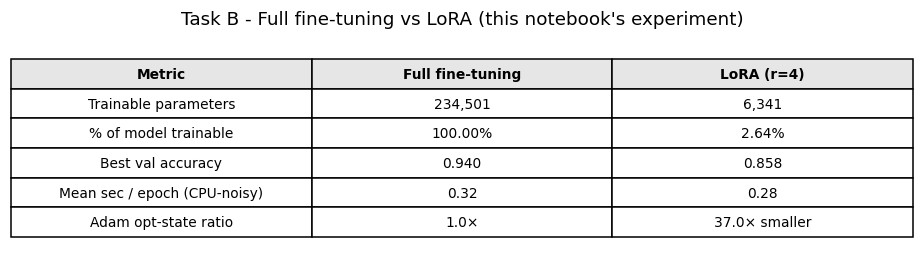

In [12]:
# Summary table
best_ft = max(hist_ft["va_acc"])
best_lo = max(hist_lo["va_acc"])
time_ft = float(np.mean(hist_ft["time"]))
time_lo = float(np.mean(hist_lo["time"]))

rows = [
    ("Metric",                "Full fine-tuning",         "LoRA (r=4)"),
    ("Trainable parameters",  f"{tr_full_b:,}",           f"{tr_lora_b:,}"),
    ("% of model trainable",  f"{100*tr_full_b/tot_full:.2f}%",
                              f"{100*tr_lora_b/tot_lora:.2f}%"),
    ("Best val accuracy",     f"{best_ft:.3f}",           f"{best_lo:.3f}"),
    ("Mean sec / epoch (CPU-noisy)", f"{time_ft:.2f}",    f"{time_lo:.2f}"),
    ("Adam opt-state ratio",  "1.0×",                     f"{tr_full_b/max(tr_lora_b,1):.1f}× smaller"),
]

fig, ax = plt.subplots(figsize=(8.5, 2.6))
ax.axis("off")
tbl = ax.table(cellText=rows, loc="center", cellLoc="center", colLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.55)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_text_props(weight="bold"); cell.set_facecolor("#e6e6e6")
ax.set_title("Task B - Full fine-tuning vs LoRA (this notebook's experiment)")
plt.tight_layout(); plt.show()


### Visualizing LoRA’s Effect on Class Predictions

The classifier gives five output scores, one for each Task B class. To make the predictions easier to visualize, we can choose any two of these scores and plot the test examples in a 2D space.

**Before LoRA adaptation**, the model uses the pretrained base, which only learned digits 0–4, plus a new randomly initialized head for Task B. Since the head has not learned anything yet and the base is frozen, the model cannot clearly separate the new classes. The points are expected to overlap a lot.

**After LoRA adaptation**, the model has trained the LoRA matrices (A) and (B), along with the classification head, on Task B. Now the model should produce more meaningful outputs, so examples from the same class should appear closer together and form clearer clusters.

This plot is a simple way to see whether LoRA has changed the prediction space. Instead of only looking at accuracy, we can visually check whether the model has learned to organize the new classes better.

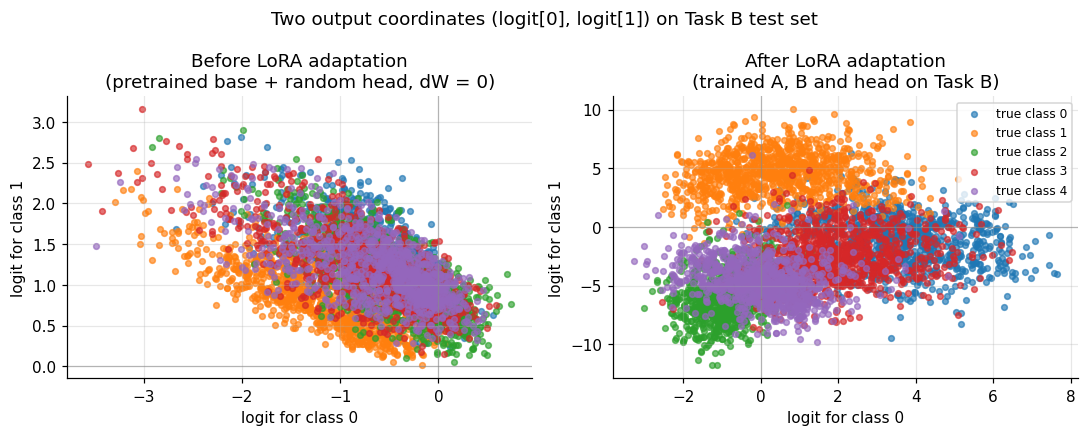

In [13]:
m_pre = make_mlp(lora_r=4, lora_alpha=4.0)
load_pretrained(m_pre, pretrained_state)
nn.init.kaiming_uniform_(m_pre.head.base.weight, a=math.sqrt(5))
nn.init.zeros_(m_pre.head.base.bias)
m_pre.to(device).eval()

# Collect the full Task B test set for evaluation
xs, ys = [], []
for xb, yb in loaders_b[1]:
    xs.append(xb); ys.append(yb)
X_test = torch.cat(xs).to(device)
y_test = torch.cat(ys).to(device)

with torch.no_grad():
    logits_pre  = m_pre(X_test).cpu()
    logits_post = m_lo.eval()(X_test).cpu()
y_test_cpu = y_test.cpu()

# Pick two class-logit axes to plot
idx_a, idx_b = 0, 1
cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
for ax_, logits, title in zip(
    axes,
    [logits_pre, logits_post],
    ["Before LoRA adaptation\n(pretrained base + random head, dW = 0)",
     "After LoRA adaptation\n(trained A, B and head on Task B)"],
):
    for c in range(5):
        mask = (y_test_cpu == c)
        ax_.scatter(logits[mask, idx_a], logits[mask, idx_b],
                    s=14, alpha=0.65, color=cmap(c),
                    label=f"true class {c}")
    ax_.axhline(0, color="grey", lw=0.8, alpha=0.5)
    ax_.axvline(0, color="grey", lw=0.8, alpha=0.5)
    ax_.set_xlabel(f"logit for class {idx_a}")
    ax_.set_ylabel(f"logit for class {idx_b}")
    ax_.set_title(title)
axes[1].legend(fontsize=8, loc="best")
plt.suptitle(f"Two output coordinates (logit[{idx_a}], logit[{idx_b}]) on Task B test set")
plt.tight_layout(); plt.show()


### Rank Sweep

Now we test how much rank LoRA really needs.

We train the LoRA model several times using different rank values:

$$
r \in \{1, 2, 4, 8, 16\}
$$

For each rank, we record two things: the best validation accuracy and the number of trainable parameters.

The LoRA shows that very small ranks, even $r = 1$, can work well in large models like GPT-3. In this notebook, we use a much smaller setup, so we expect accuracy to improve as rank increases, but the improvement may become smaller after a certain point.

r= 1  trainable=  2069  best va_acc=0.735
r= 2  trainable=  3493  best va_acc=0.788
r= 4  trainable=  6341  best va_acc=0.833
r= 8  trainable= 12037  best va_acc=0.859
r=16  trainable= 23429  best va_acc=0.898


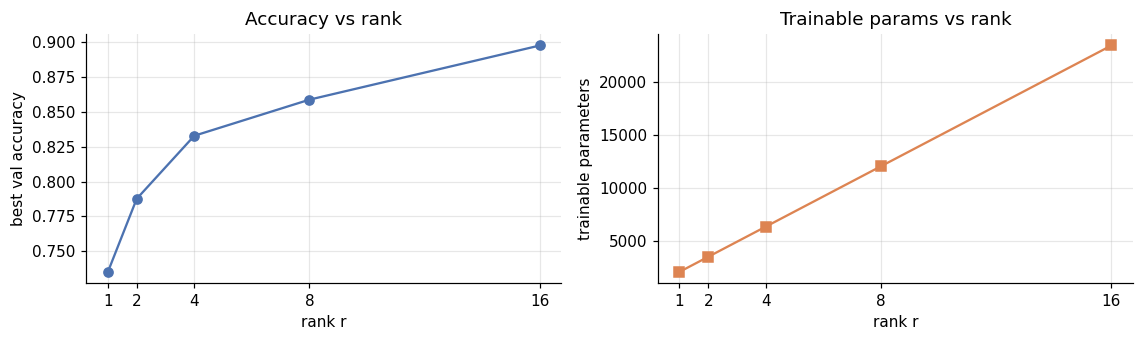

In [14]:
ranks = [1, 2, 4, 8, 16]
sweep = {"r": [], "trainable": [], "va_acc": []}

for r in ranks:
    m = make_mlp(lora_r=r, lora_alpha=float(r))
    load_pretrained(m, pretrained_state)
    nn.init.kaiming_uniform_(m.head.base.weight, a=math.sqrt(5))
    nn.init.zeros_(m.head.base.bias)
    freeze_all(m); mark_lora_trainable(m)
    m.head.base.weight.requires_grad_(True)
    m.head.base.bias.requires_grad_(True)
    tr = count_params(m)[1]
    h = train_classifier(m, *loaders_b, epochs=4, lr=1e-3, log=False)
    sweep["r"].append(r); sweep["trainable"].append(tr); sweep["va_acc"].append(max(h["va_acc"]))
    print(f"r={r:>2}  trainable={tr:>6}  best va_acc={max(h['va_acc']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
axes[0].plot(sweep["r"], sweep["va_acc"], "o-", color="#4c72b0")
axes[0].set_xlabel("rank r"); axes[0].set_ylabel("best val accuracy")
axes[0].set_title("Accuracy vs rank"); axes[0].set_xticks(ranks)

axes[1].plot(sweep["r"], sweep["trainable"], "s-", color="#dd8452")
axes[1].set_xlabel("rank r"); axes[1].set_ylabel("trainable parameters")
axes[1].set_title("Trainable params vs rank"); axes[1].set_xticks(ranks)
plt.tight_layout(); plt.show()


### Checking the Learned LoRA Update

Two final checks confirm LoRA's structural promises on our model.

**(a) Merge equivalence.** Folding $\Delta W$ into $W_0$ must not change the forward pass. If it does, merging silently changes predictions at deployment.

**(b) Singular-value spectrum of $\Delta W$.** By construction $\Delta W = BA$ has at most $r$ nonzero singular values. Their magnitude tells us *how much* of the adaptation each direction is doing.

max |unmerged - merged|       = 1.91e-06
max |unmerged - restored|     = 9.54e-07
Both should be near floating-point noise (~1e-6).


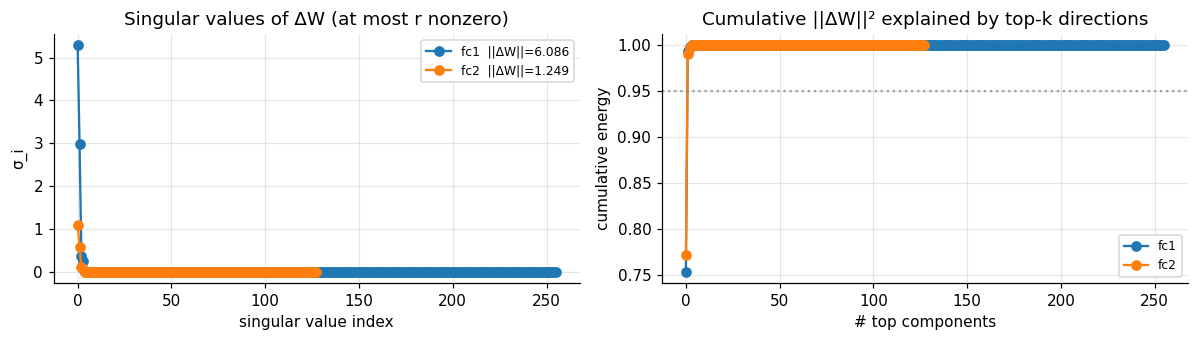

In [15]:
# (a) Merge / unmerge equivalence check on the LoRA-adapted Task-B model.
m_lo.eval()
xb = next(iter(loaders_b[1]))[0].to(device)
with torch.no_grad():
    y_unmerged = m_lo(xb).clone()
merge_all(m_lo)
with torch.no_grad():
    y_merged = m_lo(xb).clone()
unmerge_all(m_lo)
with torch.no_grad():
    y_restored = m_lo(xb).clone()

err_merge   = (y_unmerged - y_merged).abs().max().item()
err_restore = (y_unmerged - y_restored).abs().max().item()
print(f"max |unmerged - merged|       = {err_merge:.2e}")
print(f"max |unmerged - restored|     = {err_restore:.2e}")
print("Both should be near floating-point noise (~1e-6).")

# (b) Singular values of ΔW for each LoRA module.
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
for name, module in m_lo.named_modules():
    if isinstance(module, LoRALinear) and module.r > 0:
        dW = module.delta_w().detach().cpu()
        s  = torch.linalg.svdvals(dW).numpy()
        cum = np.cumsum(s**2) / (s**2).sum()
        axes[0].plot(s,  "o-", label=f"{name}  ||ΔW||={dW.norm():.3f}")
        axes[1].plot(cum,"o-", label=name)

axes[0].set_xlabel("singular value index"); axes[0].set_ylabel("σ_i")
axes[0].set_title("Singular values of ΔW (at most r nonzero)"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("# top components"); axes[1].set_ylabel("cumulative energy")
axes[1].set_title("Cumulative ||ΔW||² explained by top-k directions"); axes[1].legend(fontsize=8)
axes[1].axhline(0.95, linestyle=":", color="grey", alpha=0.7)
plt.tight_layout(); plt.show()


## Summary

This demonstrates how to understand LoRA and implement a simple version of it in PyTorch. It shows the main idea behind LoRA, how the low-rank update is trained, and how it can be merged into the base model for inference. However, there are some limitations to keep in mind.

One limitation is that mixed-task batches can be awkward after merging LoRA weights. If task A and task B need different LoRA adapters, a merged weight can only represent one task at a time. To handle multiple tasks in the same batch, we would need to keep the LoRA path unmerged or switch between adapters, which reduces some of the inference simplicity.

Another limitation is that choosing which matrices to adapt is still mostly based on experiments. The LoRA paper finds that adapting some attention matrices, such as $W_q$ and $W_v$, works well, but this choice is not a universal rule. In our smaller MLP example, there is even less guidance, so the best layer choice depends on the task.

LoRA also depends on the low-rank assumption. This means it assumes the task-specific update can be represented with a small rank $r$. This often works well, but it may not be enough when the new task is very different from the original pretraining data.

Finally, this is a tiny example. The accuracy numbers and running times are useful for understanding the idea, but they are not real benchmarks. The stronger evidence for LoRA comes from the paper’s large-scale experiments on models such as RoBERTa, DeBERTa, GPT-2, and GPT-3.

## Discussion
### 1. Weaknesses and Limitations

LoRA is very efficient, but it still has some weaknesses.

First, LoRA depends on the **low-rank assumption**. This means LoRA assumes that the update needed for a new task can be represented using a small rank. This works well in many cases, but it may not always be enough. If the new task is very different from the data used during pretraining, a very small rank may be too limited.

Another limitation is choosing where to apply LoRA. LoRA is mainly applied to Transformer attention matrices such as $W_q$ and $W_v$. This works well in their experiments, but it is still mostly an empirical choice. The best layers or matrices to adapt may depend on the model and the task.

LoRA can also be less convenient when serving many tasks at the same time. If the LoRA weights are merged into the base model for fast inference, the model can only use one adapter at a time. This makes it difficult to process different tasks with different LoRA adapters in the same batch.

Finally, LoRA does not completely remove the need for the large base model. The base model still has to be stored and loaded. LoRA only makes the task-specific updates much smaller.

### 2. Recent Research and Future Directions

A major future direction is **QLoRA**. QLoRA makes LoRA even more memory-efficient by using a frozen 4-bit quantized base model and training LoRA adapters on top of it. This allows very large models to be fine-tuned using much less GPU memory. Another direction is **AdaLoRA**. Standard LoRA often uses the same rank for many layers, but not all layers are equally important. AdaLoRA tries to solve this by giving more parameter budget to important layers and less to less important layers.

A newer improvement is **DoRA**, which stands for Weight-Decomposed Low-Rank Adaptation. DoRA separates a weight into magnitude and direction. It uses LoRA mainly to update the direction, which can improve performance while keeping the method efficient.

There is also **LoRA+**, which studies the learning rates of the two LoRA matrices. Instead of using the same learning rate for both $A$ and $B$, LoRA+ uses different learning rates to improve training.

Overall, recent research is trying to make LoRA more memory-efficient, more stable, and more automatic. The main goal is to reduce manual choices such as rank size, layer selection, and learning-rate settings.

## References
[1] E. J. Hu et al., “LoRA: Low-Rank Adaptation of Large Language Models.” 2021. Available: https://arxiv.org/abs/2106.09685

[2] J. Noble, “What is Lora (low-rank adaption)?,” IBM, https://www.ibm.com/think/topics/lora

[3] “Code lora from scratch - A lightning template by sebastian,” Lightning AI, https://lightning.ai/lightning-ai/templates/code-lora-from-scratch?section=featured

[4] M. Görner, “Are you still using Lora to fine-tune your LLM?,” Towards Data Science, https://towardsdatascience.com/are-you-still-using-lora-to-fine-tune-your-llm/

[5] Low rank adaptation (LORA): Efficient fine-tuning for real-world ai applications | by Pranjal Khadka | towards ai, https://pub.towardsai.net/low-rank-adaptation-lora-fedf37b92026?gi=f7d445bfaad4 .